In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.preprocessing import LabelEncoder

step1: Load the dataset


In [ ]:
df = pd.read_csv("C:/Users/DELL/OneDrive/Desktop/first.ipynb/project1/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
print(df["Attrition"].value_counts(normalize = True))

(1470, 35)
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


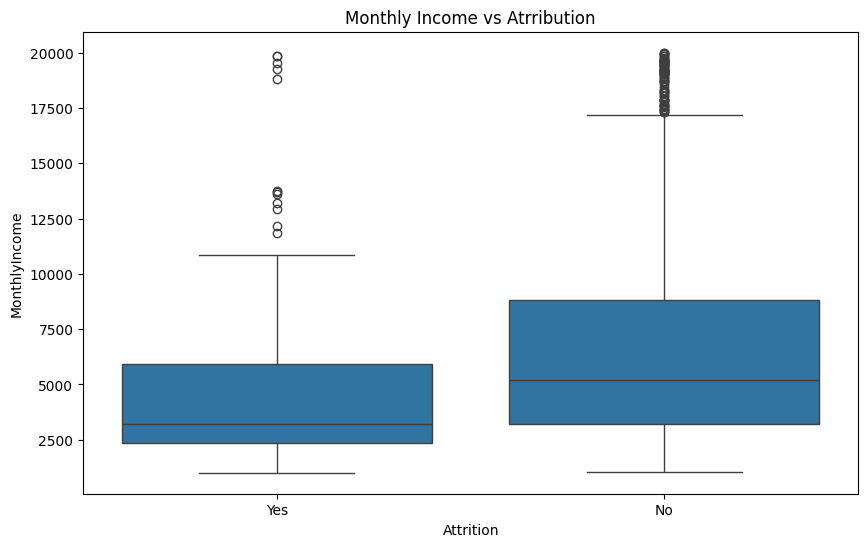

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x = "Attrition", y = "MonthlyIncome", data=df)
plt.title("Monthly Income vs Atrribution")
plt.show()

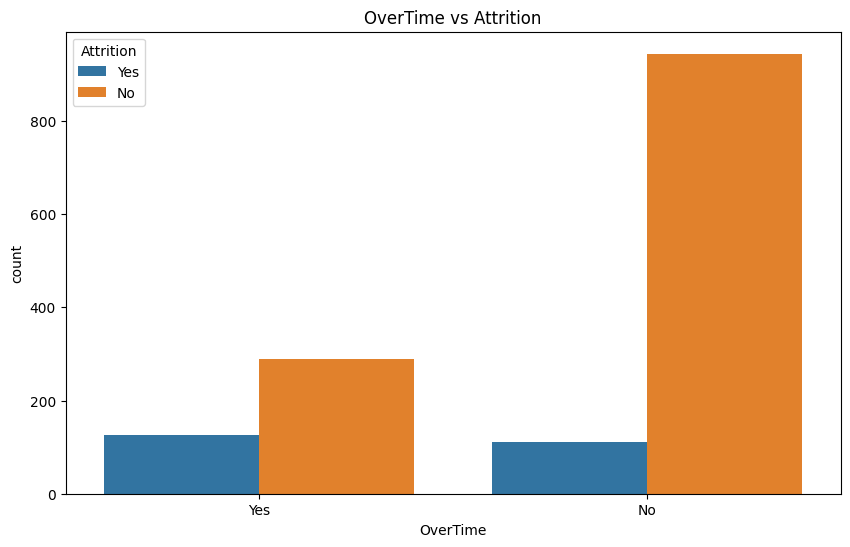

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x = "OverTime", hue = "Attrition", data=df)
plt.title("OverTime vs Attrition")
plt.show()

step3: Data Preprocessing

In [ ]:
df.drop(columns=["EmployeeNumbers","EmployeeCount","Over18","StandardHours"],inplace=True)
df.shape

In [ ]:
lb=LabelEncoder()
for col in df.select_dtypes(include=["object"]).columns:
    df[col]=lb.fit_transform(df[col])

X=df.drop("Attrition",axis=1)
y=df["Attrition"]

X_train ,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

step 4:Modeling and tunning(hyperparameter)

In [ ]:
rf=RandomForestClassifier(random_state=42)

param_grid={
    "n_estimators":[50,100],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

#GridSearchCV is computationally expensive , so we will use a smaller grid for
grid_search=GridSearchCV(rf,param_grid=param_grid,cv=5,scoring="f1")
grid_search.fit(X_train,y_train)

print("Best Parameters:",grid_search.best_params_)

step 5:Model evaluation

In [ ]:
best_model=grid_search.best_estimator_
predictions=best_model.predict(X_test)

print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))

In [ ]:
importances=pd.DataFrame({
    "Feature": X.columns,
    "Importance":best_model.feature_importances_
}).sort_values(by="Importance",ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x="Importance",y="Feature",data=importances)
plt.title("Feature Importances")
plt.show()

step 6:save the model

In [ ]:
model=RandomForestClassifier(n_estimators=50,max_depth=20,min_samples_split=5,min_samples_leaf=1,random_state=42)
model.fit(X_train,y_train)

In [ ]:
joblib.dump(model,"attrition_model.pkl")
joblib.dump(lb,"label_encoder.pkl")
joblib.dump(X.columns.to_list(),"feature_columns.pkl")